In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 

In [2]:
sys.path.append(str(Path.cwd().parent / "src"))
from data_loader import load_data

In [3]:
df = load_data()
print(df.shape)
df.head()

Found 31 parquet file(s). Loading...
Loaded 28,206,527 records.
(28206527, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,BF9B45EF846F766F,electric_bike,2025-04-05 15:18:25.360,2025-04-05 15:32:07.818,111 St & 53 Ave,6171.02,Broadway & 74 St,6332.10,40.743360,-73.851290,40.746530,-73.891210,casual
1,019D3C58B9CCA0AD,electric_bike,2025-04-02 08:58:40.957,2025-04-02 09:04:59.729,E 27 St & 1 Ave,6004.06,E 40 St & Park Ave,6432.11,40.739445,-73.976806,40.750756,-73.978326,member
2,5E68E6942DE381BD,classic_bike,2025-04-08 11:58:27.583,2025-04-08 12:06:55.120,W 113 St & Broadway,7713.01,Frederick Douglass Blvd & W 117 St,7688.12,40.805973,-73.964928,40.805159,-73.954692,member
3,801EAB661E50A4C1,electric_bike,2025-04-01 09:48:58.509,2025-04-01 09:53:00.136,Lexington Ave & E 26 St,6089.08,E 40 St & Park Ave,6432.11,40.741459,-73.983293,40.750756,-73.978326,member
4,ED609B115FB559EC,electric_bike,2025-04-09 11:15:45.418,2025-04-09 11:25:51.783,Bedford Park Blvd & Paul Ave,8752.01,Jerome Ave & E Mosholu Pkwy S,8795.01,40.874440,-73.891860,40.879350,-73.885340,member


In [ ]:
df["duration_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

print(f"Before outlier removal: {len(df):,}")
df = df[df["duration_min"] <= 180].copy()
print(f"After outlier removal:  {len(df):,}")

Before outlier removal: 28,206,527


In [ ]:
df["hour"]       = df["started_at"].dt.hour
df["dayofweek"]  = df["started_at"].dt.dayofweek   # 0=Mon, 6=Sun
df["month"]      = df["started_at"].dt.month
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

def time_of_day(hour):
    if 7 <= hour < 10:
        return "morning_rush"
    elif 10 <= hour < 17:
        return "daytime"
    elif 17 <= hour < 20:
        return "evening_rush"
    else:
        return "night"

df["time_of_day"] = df["hour"].apply(time_of_day)

print(df["time_of_day"].value_counts())

time_of_day
daytime         11083537
evening_rush     7031128
night            5812342
morning_rush     4238701
Name: count, dtype: int64


In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["start_lat"], df["start_lng"],
    df["end_lat"],   df["end_lng"]
)

print(f"distance_km NaN 수: {df['distance_km'].isna().sum():,}")
print(f"Average distance: {df['distance_km'].mean():.2f} km")
print(f"Median distance:  {df['distance_km'].median():.2f} km")

distance_km NaN 수: 77,541
Average distance: 2.08 km
Median distance:  1.56 km


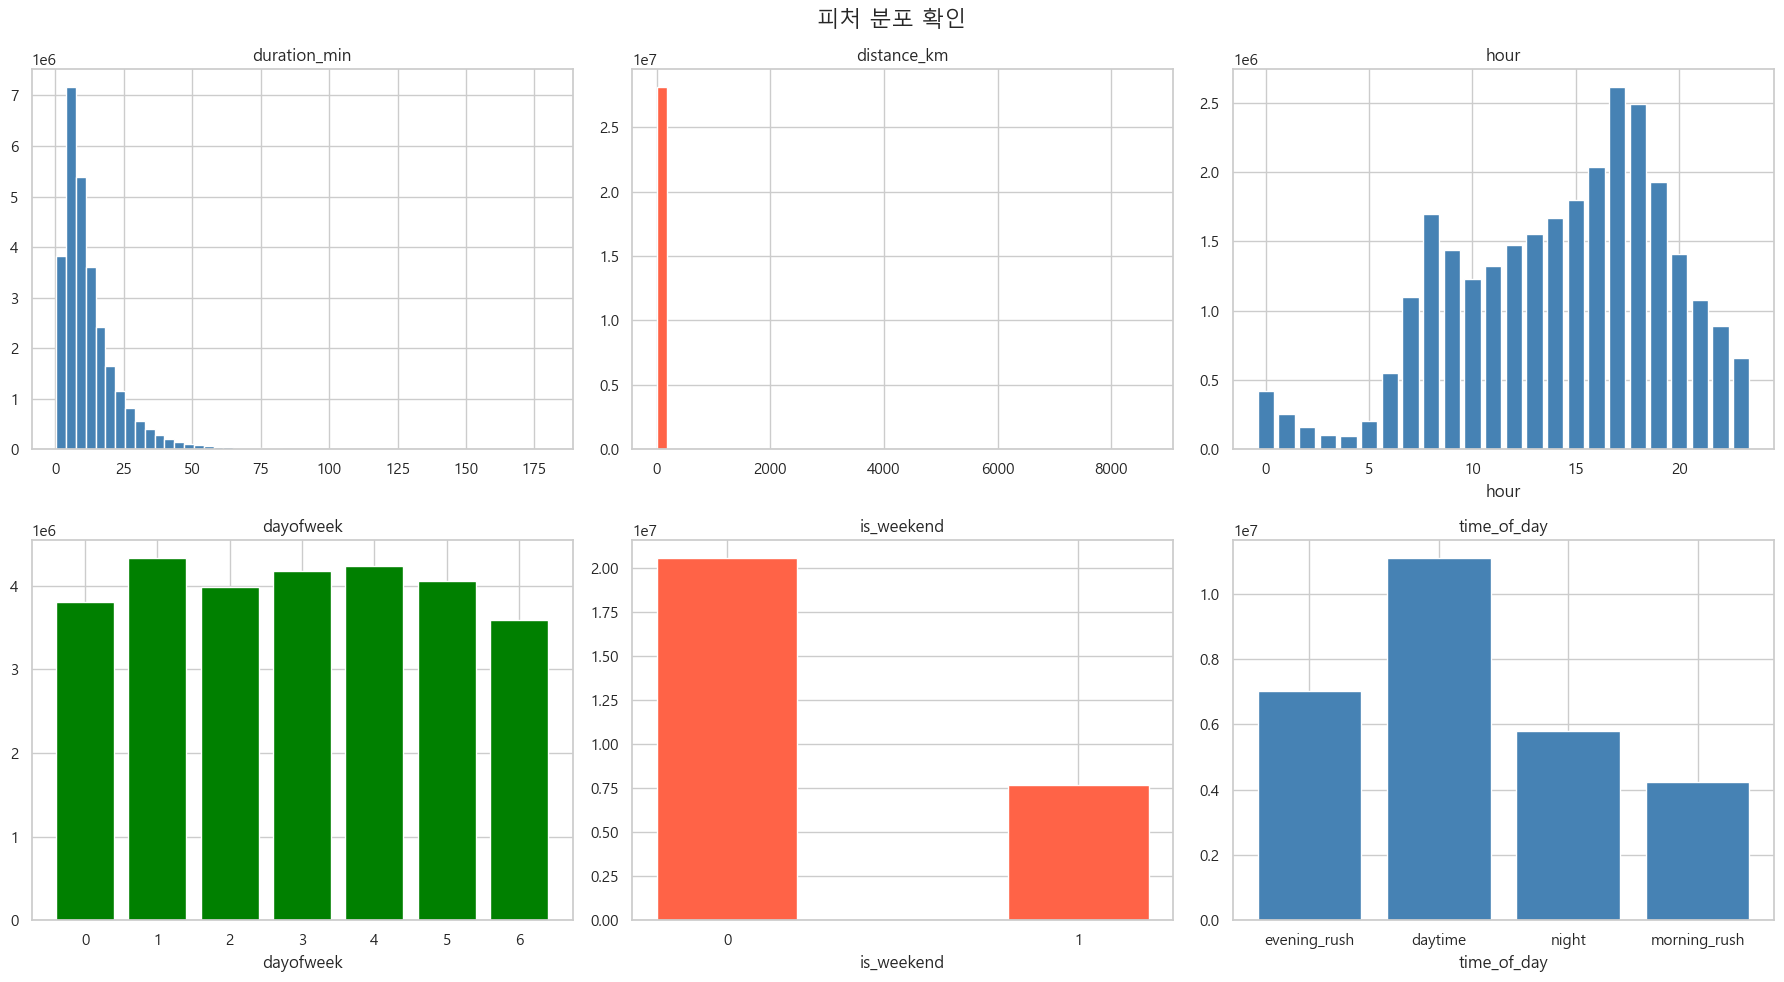

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("피처 분포 확인", fontsize=16)

# duration_min
axes[0, 0].hist(df["duration_min"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("duration_min")

# distance_km
axes[0, 1].hist(df["distance_km"].dropna(), bins=50, color="tomato", edgecolor="white")
axes[0, 1].set_title("distance_km")

# hour
hour_counts = df["hour"].value_counts().sort_index()
axes[0, 2].bar(hour_counts.index, hour_counts.values, color="steelblue")
axes[0, 2].set_title("hour")
axes[0, 2].set_xlabel("hour")

# dayofweek
dow_counts = df["dayofweek"].value_counts().sort_index()
axes[1, 0].bar(dow_counts.index, dow_counts.values, color="green")
axes[1, 0].set_title("dayofweek")
axes[1, 0].set_xlabel("dayofweek")

# is_weekend - bar()로 변경
iw_counts = df["is_weekend"].value_counts().sort_index()
axes[1, 1].bar([0, 1], iw_counts.values, color="tomato", width=0.4)
axes[1, 1].set_title("is_weekend")
axes[1, 1].set_xlabel("is_weekend")
axes[1, 1].set_xticks([0, 1])

# time_of_day
tod_order = ["evening_rush", "daytime", "night", "morning_rush"]
tod_counts = df["time_of_day"].value_counts().reindex(tod_order)
axes[1, 2].bar(tod_counts.index, tod_counts.values, color="steelblue")
axes[1, 2].set_title("time_of_day")
axes[1, 2].set_xlabel("time_of_day")

plt.tight_layout()
plt.show()

In [ ]:
hourly_demand = (
    df.groupby(df["started_at"].dt.floor("h"))
    .size()
    .reset_index(name="ride_count")
    .rename(columns={"started_at": "ds"})
    .sort_values("ds")
    .reset_index(drop=True)
)

print(f"Hourly demand records: {len(hourly_demand):,}")
print(hourly_demand.head(10))

Hourly demand records: 4,394
                   ds  ride_count
0 2025-03-31 22:00:00           1
1 2025-03-31 23:00:00          62
2 2025-04-01 00:00:00         268
3 2025-04-01 01:00:00         175
4 2025-04-01 02:00:00         141
5 2025-04-01 03:00:00         119
6 2025-04-01 04:00:00         262
7 2025-04-01 05:00:00        1055
8 2025-04-01 06:00:00        3084
9 2025-04-01 07:00:00        6888


In [ ]:
for lag in [1, 2, 3, 24, 48, 168]:
    hourly_demand[f"lag_{lag}h"] = hourly_demand["ride_count"].shift(lag)

In [ ]:
for window in [24, 168]:
    hourly_demand[f"rolling_mean_{window}h"] = (
        hourly_demand["ride_count"].shift(1).rolling(window).mean()
    )
    hourly_demand[f"rolling_std_{window}h"] = (
        hourly_demand["ride_count"].shift(1).rolling(window).std()
    )

hourly_demand.dropna(inplace=True)
hourly_demand.reset_index(drop=True, inplace=True)

print(hourly_demand.shape)
hourly_demand.head()

(4226, 12)


,ds,ride_count,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,lag_168h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h
0,2025-04-07 22:00:00,2214,3172.0,4549.0,5839.0,2278.0,2727.0,1.0,2985.666667,2166.683795,4422.190476,3443.606562
1,2025-04-07 23:00:00,1699,2214.0,3172.0,4549.0,1761.0,2499.0,62.0,2983.000000,2167.631807,4435.363095,3430.802002
2,2025-04-08 00:00:00,808,1699.0,2214.0,3172.0,917.0,950.0,268.0,2980.416667,2169.187865,4445.107143,3420.616102
3,2025-04-08 01:00:00,399,808.0,1699.0,2214.0,486.0,538.0,175.0,2975.875000,2173.805105,4448.321429,3416.919168
4,2025-04-08 02:00:00,238,399.0,808.0,1699.0,263.0,458.0,141.0,2972.250000,2178.205788,4449.654762,3415.284982


In [ ]:
out_path = Path.cwd().parent / "data" / "processed" / "hourly_demand.parquet"
hourly_demand.to_parquet(out_path, index=False)